# GoEmotions Dataset Exploration

This notebook performs a focused exploratory data analysis (EDA) of the GoEmotions dataset.

It covers:
- dataset structure and data quality checks
- emotion label distribution and imbalance
- text-level analysis (length statistics)
- lexical patterns (word cloud + n-grams)
- a quick look at the `example_very_unclear` flag

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

tqdm.pandas()

Matplotlib is building the font cache; this may take a moment.
/Users/mac-SAITSI15/Desktop/goemotions/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Load Data And Basic Preview

We first load the CSV, inspect shape and columns, and view a small sample.

In [10]:
data_path = "../dataset/go_emotions_dataset.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Number of columns: {len(df.columns)}")
print("\nFirst 10 columns:", list(df.columns[:10]))

display(df.head(3))

Dataset shape: (211225, 31)
Number of columns: 31

First 10 columns: ['id', 'text', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion']


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


## 2) Structure And Data Quality

This section checks data types, missing values, duplicate rows, and identifies key column groups (`text`, `metadata`, and binary emotion labels).

In [11]:
print("DataFrame info:")
display(df.info())

missing_counts = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_count}")
print("\nColumns with missing values:")
display(missing_counts[missing_counts > 0])

text_col = "text" if "text" in df.columns else None
metadata_cols = [c for c in ["id", "example_very_unclear"] if c in df.columns]

label_cols = [
    c for c in df.columns
    if c not in metadata_cols + ([text_col] if text_col else [])
    and set(pd.Series(df[c]).dropna().unique()).issubset({0, 1, True, False})
]

print(f"Detected text column: {text_col}")
print(f"Detected metadata columns: {metadata_cols}")
print(f"Detected binary label columns: {len(label_cols)}")
print("First 10 labels:", label_cols[:10])

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    211225 non-null  str  
 1   text                  211225 non-null  str  
 2   example_very_unclear  211225 non-null  bool 
 3   admiration            211225 non-null  int64
 4   amusement             211225 non-null  int64
 5   anger                 211225 non-null  int64
 6   annoyance             211225 non-null  int64
 7   approval              211225 non-null  int64
 8   caring                211225 non-null  int64
 9   confusion             211225 non-null  int64
 10  curiosity             211225 non-null  int64
 11  desire                211225 non-null  int64
 12  disappointment        211225 non-null  int64
 13  disapproval           211225 non-null  int64
 14  disgust               211225 non-null  int64
 15  embarrassment         211225 

None


Duplicate rows: 56737

Columns with missing values:


Series([], dtype: int64)

Detected text column: text
Detected metadata columns: ['id', 'example_very_unclear']
Detected binary label columns: 28
First 10 labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment']


## 3) Label Distribution And Imbalance

GoEmotions is a multi-label dataset, so a row can belong to multiple emotions. We measure how frequent each label is and how many labels each sample contains.

Top 10 most frequent labels:


,count
neutral,55298
approval,17620
admiration,17131
annoyance,13618
gratitude,11625
disapproval,11424
curiosity,9692
amusement,9245
realization,8785
optimism,8715


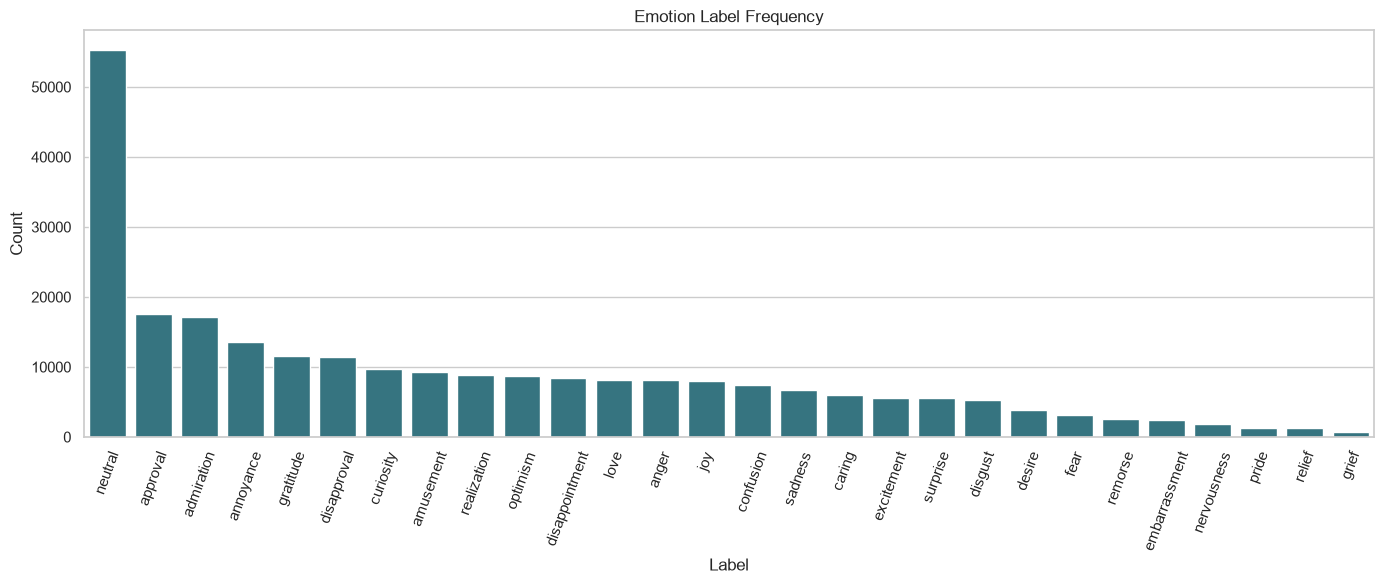

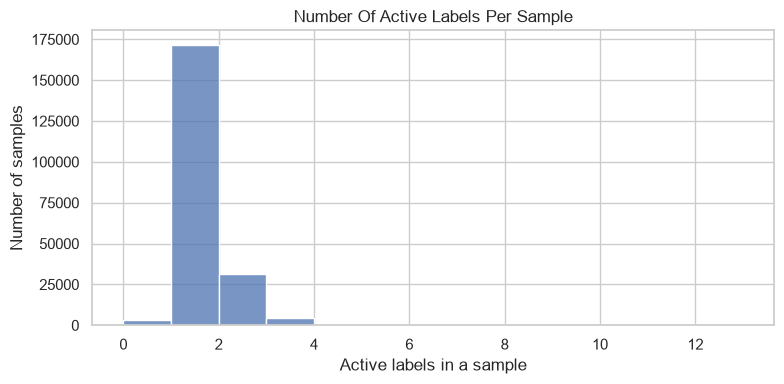

Labels per sample summary:


count    211225.000000
mean          1.181342
std           0.498757
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          12.000000
dtype: float64

In [16]:
label_matrix = df[label_cols].astype(int)
label_freq = label_matrix.sum().sort_values(ascending=False)
labels_per_sample = label_matrix.sum(axis=1)

print("Top 10 most frequent labels:")
display(label_freq.head(10).to_frame("count"))

plt.figure(figsize=(14, 6))
sns.barplot(x=label_freq.index, y=label_freq.values, color=sns.color_palette("crest", 8)[4])
plt.xticks(rotation=70)
plt.title("Emotion Label Frequency")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(labels_per_sample, bins=range(labels_per_sample.min(), labels_per_sample.max() + 2), kde=False)
plt.title("Number Of Active Labels Per Sample")
plt.xlabel("Active labels in a sample")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

print("Labels per sample summary:")
display(labels_per_sample.describe())

## 4) Text Analysis

We inspect text length patterns and identify labels associated with longer comments.

Text length summary:


,char_len,word_len
count,211225.000000,211225.000000
mean,69.299572,12.997188
std,36.536746,6.676105
min,2.000000,1.000000
25%,39.000000,7.000000
50%,67.000000,13.000000
75%,97.000000,18.000000
max,703.000000,33.000000


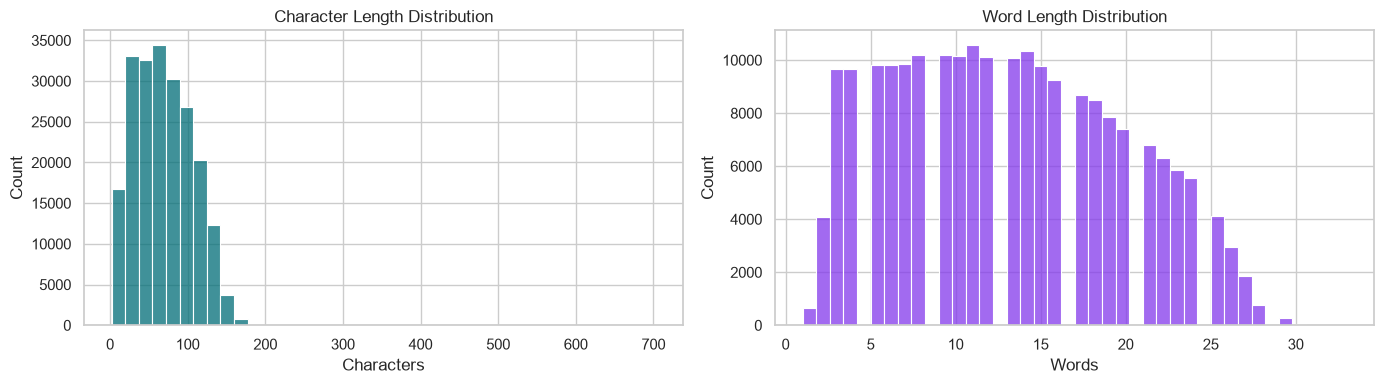

Computing mean text length by label: 100%|██████████| 28/28 [00:00<00:00, 3803.86it/s]

Top 10 labels by average word length:


,avg_word_len
optimism,15.342857
realization,15.227661
desire,14.788839
nervousness,14.606077
disappointment,14.564175
confusion,14.389591
embarrassment,14.383279
disapproval,14.349965
caring,14.290882
annoyance,14.089514


In [23]:
df["char_len"] = df[text_col].fillna("").str.len()
df["word_len"] = df[text_col].fillna("").str.split().str.len()

print("Text length summary:")
display(df[["char_len", "word_len"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["char_len"], bins=40, ax=axes[0], color="#006d77")
axes[0].set_title("Character Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(df["word_len"], bins=40, ax=axes[1], color="#8338ec")
axes[1].set_title("Word Length Distribution")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

label_mean_word_len = {}
for col in tqdm(label_cols, desc="Computing mean text length by label"):
    positives = df.loc[df[col] == 1, "word_len"]
    label_mean_word_len[col] = positives.mean() if len(positives) else np.nan

label_mean_word_len = pd.Series(label_mean_word_len).sort_values(ascending=False)
print("Top 10 labels by average word length:")
display(label_mean_word_len.head(10).to_frame("avg_word_len"))

## 5) Lexical Exploration

Generate a global word cloud and frequent n-grams to understand the vocabulary that appears most often in the dataset.

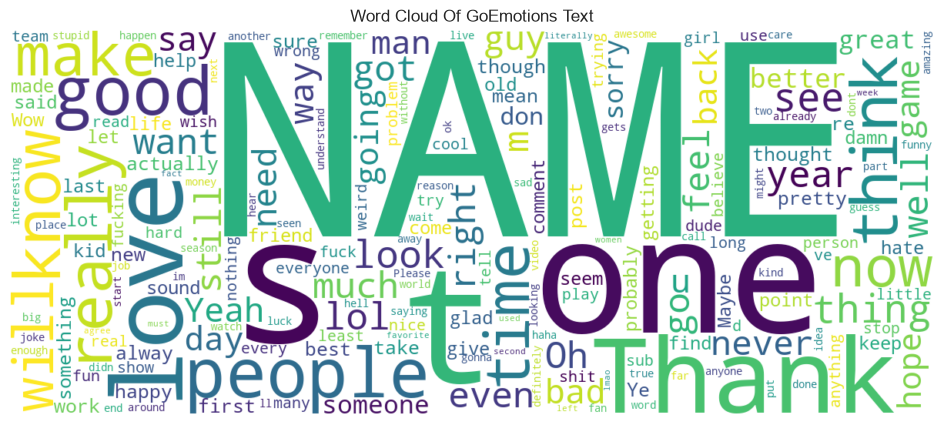

,term,count
0,just,17219
1,like,16421
2,don,10639
3,people,8745
4,love,8415
5,good,8284
6,think,7221
7,really,7134
8,know,7111
9,time,5863


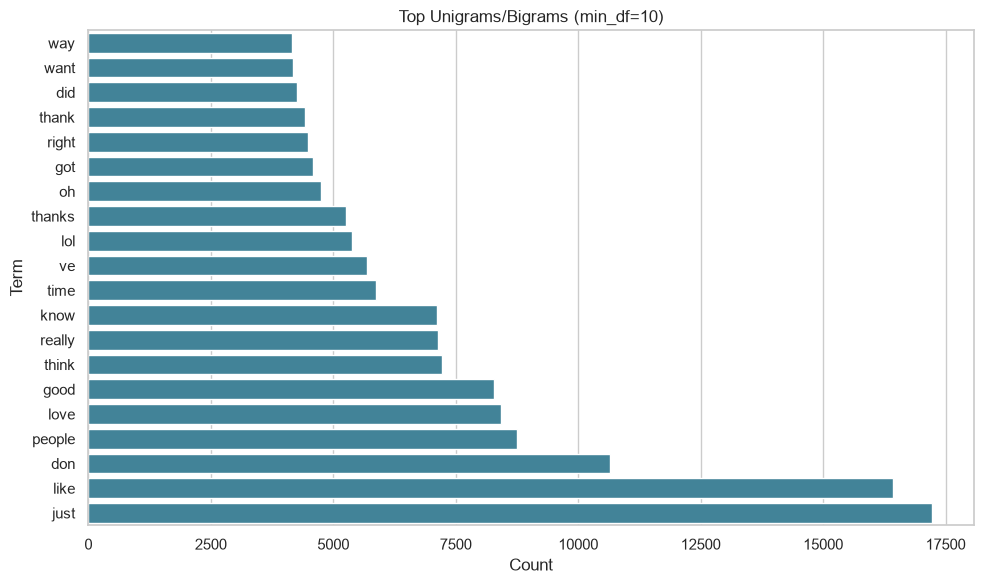

In [17]:
all_text = " ".join(df[text_col].fillna("").astype(str).tolist())

wc = WordCloud(
    width=1200,
    height=500,
    background_color="white",
    stopwords=set(STOPWORDS),
    collocations=False,
    max_words=200,
).generate(all_text)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Of GoEmotions Text")
plt.show()

vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=10)
X = vectorizer.fit_transform(df[text_col].fillna(""))

token_counts = np.asarray(X.sum(axis=0)).ravel()
terms = np.array(vectorizer.get_feature_names_out())

top_n = 20
top_idx = token_counts.argsort()[::-1][:top_n]
top_terms = pd.DataFrame({
    "term": terms[top_idx],
    "count": token_counts[top_idx],
})

display(top_terms)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_terms.sort_values("count", ascending=True), x="count", y="term", color=sns.color_palette("mako", 8)[4])
plt.title("Top Unigrams/Bigrams (min_df=10)")
plt.xlabel("Count")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

## 6) Optional Slice: Very Unclear Examples

If the `example_very_unclear` flag exists, compare how these samples differ in text length and label cardinality.

In [18]:
if "example_very_unclear" in df.columns:
    unclear = df["example_very_unclear"].astype(str).str.lower().isin(["true", "1"])
    active_labels_per_sample = label_matrix.sum(axis=1)

    comparison = pd.DataFrame({
        "avg_word_len": df.groupby(unclear)["word_len"].mean(),
        "avg_active_labels": active_labels_per_sample.groupby(unclear).mean(),
        "count": unclear.value_counts().sort_index(),
    })
    comparison.index = ["clear_or_not_flagged", "very_unclear"]
    display(comparison)
else:
    print("Column 'example_very_unclear' not found; skipping this section.")

,avg_word_len,avg_active_labels,count
clear_or_not_flagged,13.022703,1.200732,207814
very_unclear,11.442685,0.000000,3411
